<a href="https://colab.research.google.com/github/Eikthyrnir/CatVTON_3DGS/blob/main/CatVTON_sandbox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CatVTON basic front inference example

## CatVTON installation

In [ ]:
# Клонируем репозиторий CatVTON
!git clone https://github.com/Zheng-Chong/CatVTON.git
%cd CatVTON

In [ ]:
# Устанавливаем зависимости из requirements.txt
!pip install -r requirements.txt

In [ ]:
# Обновляем accelerate до последней версии (1.13.0) и ставим стабильный diffusers
!pip install -U accelerate==1.13.0 diffusers==0.30.3 peft huggingface_hub

In [ ]:
# Clean up existing conflicting installations first
!pip uninstall -y torch torchvision torchaudio xformers

# Upgrade setuptools to provide the distutils shim required by Python 3.12
!pip install setuptools --upgrade

# Устанавливаем PyTorch 2.4.1 (CUDA 12.4) и совместимую с Python 3.12 версию xformers
!pip install torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1 --index-url https://download.pytorch.org/whl/cu124
!pip install xformers==0.0.28.post1

In [ ]:
!nvcc --version

import torch
print("PyTorch version:", torch.__version__)
print("PyTorch CUDA version:", torch.version.cuda)

## Load sample garment and person

In [ ]:
import urllib.request

# test human-model image (front view)
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/Zheng-Chong/CatVTON/main/resource/demo/example/person/men/model_5.png",
    "person.png"
)

# test garment image
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/Zheng-Chong/CatVTON/main/resource/demo/example/condition/upper/24083449_54173465_2048.jpg",
    "garment.jpg"
)

## CatVTON imports

In [ ]:
%cd CatVTON

In [ ]:
%ls

In [ ]:
import torch
from PIL import Image
from huggingface_hub import snapshot_download

import os
import gc

# imports from CatVTON
from model.cloth_masker import AutoMasker
from model.pipeline import CatVTONPipeline

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

## Initializing CatVTON models

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
from diffusers import AutoencoderKL
import torch

weight_dtype = torch.float16

base_model_path = "runwayml/stable-diffusion-inpainting"
catvton_model_path = "zhengchong/CatVTON"

pipeline = CatVTONPipeline(
    base_ckpt=base_model_path,
    attn_ckpt=catvton_model_path,
    attn_ckpt_version="mix",
    weight_dtype=weight_dtype,
    device=device,
    skip_safety_check=True
)

# Fix for the pink mask overlay and brown artifacts on T4:
# We use the official MSE-finetuned VAE which is safe in float16 and maintains high quality.
pipeline.vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse", torch_dtype=weight_dtype).to(device)

# Built-in memory optimization
try:
    pipeline.enable_xformers_memory_efficient_attention()
    print("xformers optimization enabled.")
except Exception:
    print("Using built-in SDPA optimization.")

try:
    if hasattr(pipeline, "enable_model_cpu_offload"):
        pipeline.enable_model_cpu_offload()
        print("CPU offloading enabled!")
except Exception as e:
    print(f"Failed to enable CPU offloading: {e}")

In [ ]:
# Скачиваем основной репозиторий с весами (или берем из кэша)
repo_path = snapshot_download(repo_id="zhengchong/CatVTON")

# Инициализация модуля для автоматического создания масок с использованием путей внутри основного репозитория
automasker = AutoMasker(
    densepose_ckpt=os.path.join(repo_path, "DensePose"),
    schp_ckpt=os.path.join(repo_path, "SCHP"),
    device=device
)

## Utility functions

In [ ]:
def show_try_on_res(person, mask, try_on_result):
    fig, axs = plt.subplots(1, 3, figsize=(15, 6))

    axs[0].imshow(person)
    axs[0].set_title("Front Result (Reference)")
    axs[0].axis('off')

    axs[1].imshow(mask)
    axs[1].set_title("Try-On Mask")
    axs[1].axis('off')

    axs[2].imshow(try_on_result.resize(target_size))
    axs[2].set_title("Try-On Result")
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def show_multiple_images(images):
    n_images = len(images)
    fig, axs = plt.subplots(1, n_images, figsize=(5 * n_images, 6))

    if n_images == 1:
        axs.imshow(images[0])
        axs.axis('off')
    else:
        for i in range(n_images):
            axs[i].imshow(images[i])
            axs[i].axis('off')

    plt.tight_layout()
    plt.show()

## Connect to Google Drive
It is convenient to load data from external source than manually drag it into colab env

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Alternative to mounting google drive: upload only few necessary files from local computer

# from google.colab import files

# uploaded = files.upload()

# for fn in uploaded.keys():
#   print('User uploaded file "{name}" with length {length} bytes'.format(
#       name=fn, length=len(uploaded[fn])))

## Copy files from drive

In [ ]:
!mkdir /content/clothes
!cp -r /content/drive/MyDrive/weavella/images/cloth_from_zoolando_website /content/clothes

## Example inference on front view

In [ ]:
# NOT SURE IF WE REALLY NEED IT
# Clean up the patches (we are back to a standard KL VAE, so we need original functions)

# import utils
# import model.pipeline
# import importlib

# NOT SURE IF WE REALLY NEED IT
# Reloading restores the default CatVTON behavior that works with AutoencoderKL
# importlib.reload(utils)
# importlib.reload(model.pipeline)


In [ ]:
NUM_INFERENCE_STEPS_CAT_VTON = 50

In [ ]:
# 1. Load images
person_path = "/content/person.png"
# garment_path = "/content/garment.jpg"
garment_folder = "/content/clothes/cloth_from_zoolando_website/jack-and-jones-jorsnake-crew-neck-t-shirt-z-nadrukiem-antique-white-ja222o5zp-a11"
# On person
garment_path = garment_folder + "/6d51a17dfd0343a5a27b5971c92bfae9.webp"
garment_path = garment_folder + "/c4894c7140ca48f6af9b8cd05c2adc25.webp"
garment_path = garment_folder + "/9cbddc78aa24472e87bdec578049891c.webp"
garment_path = garment_folder + "/833fd6835df54ece81b53c66de90dd48.webp"
# pure flat-out t-shirt image
garment_path = garment_folder + "/c238569c66eb42578c5a787c54e43731.webp"
garment_path = garment_folder + "/ceac3aa9af9b451d8aa29df6cf5db6dc.webp"

person_image = Image.open(person_path).convert("RGB")
garment_image = Image.open(garment_path).convert("RGB")

# size of the images for CatVTON
target_size = (768, 1024)
person_image = person_image.resize(target_size)
garment_image = garment_image.resize(target_size)

In [ ]:
for proc in pipeline.unet.attn_processors.values():
    if isinstance(proc, ReferenceAttentionProcessor):
        proc.is_reference_pass = True
        proc.clear_bank()

In [ ]:
# 1. Clear memory before running
torch.cuda.empty_cache()
gc.collect()

# 2. Generate mask
print("Generating mask...")
mask_result = automasker(person_image)
mask = mask_result['mask']

# 3. Run inference

print("Running inference (try-on). This may take a couple of minutes...")

# Use the same noise generator for stability
generator = torch.Generator(device=device).manual_seed(42)

result_image = pipeline(
    image=person_image,
    condition_image=garment_image,
    mask=mask,
    num_inference_steps=NUM_INFERENCE_STEPS_CAT_VTON,
    guidance_scale=2.5,
    generator=generator
)[0]

In [ ]:
show_multiple_images((person_image, garment_image, mask, result_image))

# Modifying the U-Net for Reference-Driven Editing (consistent side-view try-on generation)

## Defining custon Reference Attention Processor

In [ ]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from diffusers.models.attention_processor import Attention

class ReferenceAttentionProcessor:
    def __init__(self):
        self.is_reference_pass = True
        self.bank_k = []
        self.bank_v = []
        self.step_idx = 0

    def clear_bank(self):
        self.bank_k.clear()
        self.bank_v.clear()
        self.step_idx = 0

    def reset_read_index(self):
        self.step_idx = 0

    def __call__(
        self,
        attn: Attention,
        hidden_states: torch.Tensor,
        encoder_hidden_states=None,
        attention_mask=None,
        **kwargs,
    ):
        batch_size, sequence_length, _ = hidden_states.shape

        # 1. Get Q, K, V using built-in attention layers
        query = attn.to_q(hidden_states)
        key = attn.to_k(hidden_states)
        value = attn.to_v(hidden_states)

        inner_dim = key.shape[-1]
        head_dim = inner_dim // attn.heads

        # Transform dimensions to 4D for Flash Attention: (batch, heads, seq_len, head_dim)
        query = query.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        key = key.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        value = value.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)

        if self.is_reference_pass:
            # ОФФЛОАД НА CPU: сохраняем K и V в оперативную память
            self.bank_k.append(key.clone().detach().cpu())
            self.bank_v.append(value.clone().detach().cpu())
        else:
            # Извлекаем K и V строго для СООТВЕТСТВУЮЩЕГО шага
            if self.step_idx < len(self.bank_k):
                # ВОЗВРАТ НА GPU: переносим нужный тензор обратно в память видеокарты
                ref_k = self.bank_k[self.step_idx].to(key.device)
                ref_v = self.bank_v[self.step_idx].to(value.device)

                # Handle batch mismatch (due to Classifier-Free Guidance)
                if key.shape[0] != ref_k.shape[0]:
                    multiplier = key.shape[0] // ref_k.shape[0]
                    ref_k = ref_k.repeat(multiplier, 1, 1, 1)
                    ref_v = ref_v.repeat(multiplier, 1, 1, 1)

                # Concatenate along the spatial dimension (dim=2 in 4D tensor)
                key = torch.cat([ref_k, key], dim=2)
                value = torch.cat([ref_v, value], dim=2)

                self.step_idx += 1

        # 3. Memory-efficient Attention computation (SDPA)
        # Using 4D tensors enables memory-efficient / Flash Attention in PyTorch
        with torch.backends.cuda.sdp_kernel(enable_flash=True, enable_math=False, enable_mem_efficient=True):
            try:
                hidden_states = F.scaled_dot_product_attention(
                    query, key, value, dropout_p=0.0, is_causal=False
                )
            except RuntimeError:
                # Fallback to math if necessary
                with torch.backends.cuda.sdp_kernel(enable_flash=True, enable_math=True, enable_mem_efficient=True):
                    hidden_states = F.scaled_dot_product_attention(
                        query, key, value, dropout_p=0.0, is_causal=False
                    )

        # Reshape back to expected format
        hidden_states = hidden_states.transpose(1, 2).reshape(batch_size, -1, attn.heads * head_dim)

        # Linear projections and dropout
        hidden_states = attn.to_out[0](hidden_states)
        if len(attn.to_out) > 1:
            hidden_states = attn.to_out[1](hidden_states)

        return hidden_states

# --- Integration into CatVTON pipeline ---
# 2. Replace standard attention layers in U-Net with our custom one ONLY for up_blocks!
attn_processors = {}
for name in pipeline.unet.attn_processors.keys():
    # Инициализируем наш кастомный процессор только для attn1 в up_blocks
    if "attn1" in name and "up_blocks" in name:
        print(f"replaced attn_processors[{name}] = {pipeline.unet.attn_processors.get(name, None)} with custom attention processor")
        attn_processors[name] = ReferenceAttentionProcessor()
    else:
        # Для всех остальных слоев (включая down_blocks и mid_block) оставляем дефолтные оптимизированные процессоры
        attn_processors[name] = pipeline.unet.attn_processors[name]

pipeline.unet.set_attn_processor(attn_processors)


## Testing Reference-Driven Editing (View Consistency)

For this test, we use `person.png` as the front view (reference) and a new image `person_side.png` as the side view.
*Please make sure you have uploaded `person_side.png` to Colab before running the code below.*

In [ ]:
# Image paths in Tim's google drive
person_folder = "/content/drive/MyDrive/weavella/images/Photos_Manual_Selection/1"

front_person_path = person_folder + "/IMG_6508.JPG"
# side_person_path  = person_folder + "/IMG_6518.JPG"
side_person_path  = person_folder + "/IMG_6529.JPG"

# Load, rotate 90 degrees, and resize
target_size = (512, 768)
front_person_img = Image.open(front_person_path).convert("RGB").rotate(-90, expand=True).resize(target_size)
side_person_img = Image.open(side_person_path).convert("RGB").rotate(-90, expand=True).resize(target_size)


In [ ]:
show_multiple_images((Image.open(front_person_path).convert("RGB"), front_person_img, side_person_img))

In [ ]:
# Generate masks using automasker
print("Generating mask for front view...")
front_mask = automasker(front_person_img)['mask']

print("Generating mask for side view...")
side_mask = automasker(side_person_img)['mask']

# Use the same noise generator for stability
generator = torch.Generator(device=device).manual_seed(42)

print("\n--- PASS 1: Reference Generation (Front) ---")
# Tell processor this is a reference pass (save features)
for proc in pipeline.unet.attn_processors.values():
    if isinstance(proc, ReferenceAttentionProcessor):
        proc.is_reference_pass = True
        proc.clear_bank()

front_result = pipeline(
    image=front_person_img,
    condition_image=garment_image,
    mask=front_mask,
    num_inference_steps=NUM_INFERENCE_STEPS_CAT_VTON,
    guidance_scale=2.5,
    generator=generator
)[0]

print("\n--- PASS 2: Target View Generation (Side) ---")

# Use the same noise generator for stability
generator = torch.Generator(device=device).manual_seed(42)

# Tell processor to use saved features
for proc in pipeline.unet.attn_processors.values():
    if isinstance(proc, ReferenceAttentionProcessor):
        proc.is_reference_pass = False
        proc.reset_read_index()

side_result = pipeline(
    image=side_person_img,
    condition_image=garment_image,
    mask=side_mask,
    num_inference_steps=NUM_INFERENCE_STEPS_CAT_VTON,
    guidance_scale=2.5,
    generator=generator
)[0]

In [ ]:
show_multiple_images((front_result, side_mask, side_result))

# Complete pipeline test on vadim video

## Install camenduru 3DGS (3DGS version for colab)

In [ ]:
%cd /content
!git clone --recursive https://github.com/camenduru/gaussian-splatting
!pip install -q plyfile ninja

In [ ]:
%cd /content/gaussian-splatting

In [ ]:
import sys
!{sys.executable} -m pip install setuptools==69.0.3

In [ ]:
!{sys.executable} -m pip install -q /content/gaussian-splatting/submodules/diff-gaussian-rasterization

In [ ]:
import os
os.environ['CUDA_HOME'] = '/usr/local/cuda'

In [ ]:
!sed -i '1i #include <float.h>' /content/gaussian-splatting/submodules/simple-knn/simple_knn.cu

%cd /content/gaussian-splatting
!pip install ./submodules/simple-knn

## Split video into images

In [ ]:
!mkdir -p /content/gaussian-splatting/input/vadim
!cp /content/drive/MyDrive/weavella/images/Photos_Manual_Selection/9/vadim.MOV /content/gaussian-splatting/input/vadim/

In [ ]:
!mkdir -p /content/gaussian-splatting/input/vadim/init_frames
!ffmpeg -i /content/gaussian-splatting/input/vadim/vadim.MOV -qscale: 1 -qmin 1 -vf fps=2 /content/gaussian-splatting/input/vadim/init_frames/%04d.jpg

In [ ]:
# Copy video frames folder to Google Drive
!cp -r /content/gaussian-splatting/input/vadim/input /content/drive/MyDrive/weavella/images/Photos_Manual_Selection/9

## Use CatVTON to try-on cloth on user from different angles

In [ ]:
target_size = (768, 1024)

In [ ]:
# different front-back
garment_folder = "/content/clothes/cloth_from_zoolando_website/jack-and-jones-jorsnake-crew-neck-t-shirt-z-nadrukiem-antique-white-ja222o5zp-a11"
# pure flat-out t-shirt image
front_garment_path = garment_folder + "/c238569c66eb42578c5a787c54e43731.webp"
back_garment_path  = garment_folder + "/ceac3aa9af9b451d8aa29df6cf5db6dc.webp"

front_garment_image = Image.open(front_garment_path).convert("RGB").resize(target_size)
back_garment_image  = Image.open(back_garment_path).convert("RGB").resize(target_size)

In [ ]:
# different front-back + side image
garment_folder = "/content/clothes/cloth_from_zoolando_website/the-north-face-retro-earth-short-sleeve-graphic-t-shirt-z-nadrukiem-white-dune-th322o0e8-a11"
# pure flat-out t-shirt image
front_garment_path = garment_folder + "/e8cb036024b94af8aaeb5b8d38dfcb7c.webp"
back_garment_path  = garment_folder + "/95c143c6284549e99409498bf1b92679.webp"
side_garment_path  = garment_folder + "/c172d2683ba54fe299fdbc6b5023658d.webp"

front_garment_image = Image.open(front_garment_path).convert("RGB").resize(target_size)
back_garment_image  = Image.open(back_garment_path).convert("RGB").resize(target_size)
side_garment_image  = Image.open(side_garment_path).convert("RGB").resize(target_size)

In [ ]:
person_folder = "/content/gaussian-splatting/input/vadim/init_frames"

front_person_path = person_folder + "/0012.jpg"
back_person_path  = person_folder + "/0041.jpg"

# Load and resize
front_person_img = Image.open(front_person_path).convert("RGB").resize(target_size)
back_person_img  = Image.open(back_person_path).convert("RGB").resize(target_size)

## Funcs to determine body position/rotation

In [ ]:
def two_phase_tryon(person_img, garment_img, automasker, pipeline, coarse_steps=20, fine_steps=50, dilate_iter=5):
    # --- Phase 1: Coarse Try-On ---
    print("Phase 1: Generating Coarse Mask and Try-On...")
    coarse_mask_result = automasker(person_img)
    coarse_mask = coarse_mask_result['mask']

    generator = torch.Generator(device=device).manual_seed(42)
    coarse_result = pipeline(
        image=person_img,
        condition_image=garment_img,
        mask=coarse_mask,
        num_inference_steps=coarse_steps,
        guidance_scale=2.5,
        generator=generator
    )[0]

    # --- Phase 2: Fine Mask Refinement ---
    print("Phase 2: Refining Mask from Coarse Result...")
    # Run automasker on the coarse result to get exact boundaries of the new garment
    fine_mask_result = automasker(coarse_result)

    # Extract the Upper-clothes mask from SCHP lip (index 5)
    schp_lip = np.array(fine_mask_result['schp_lip'])
    upper_clothes_mask = (schp_lip == 5).astype(np.uint8) * 255

    # --- Fix Holes and Small Artifacts ---
    # 1. Morphological Opening (removes small white artifacts/noise in the background)
    kernel_small = np.ones((5, 5), np.uint8)
    cleaned_mask = cv2.morphologyEx(upper_clothes_mask, cv2.MORPH_OPEN, kernel_small)

    # 2. Fill internal holes (like the ear-sized hole) using Contours
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled_mask = np.zeros_like(cleaned_mask)
    cv2.drawContours(filled_mask, contours, -1, 255, thickness=cv2.FILLED)

    # --- Dilation for blending ---
    kernel = np.ones((5, 5), np.uint8)
    refined_mask_np = cv2.dilate(filled_mask, kernel, iterations=dilate_iter)

    # --- Restore Intentional Holes (Bags, Belts, Hair) ---
    # Use the ATR segmentation map to find accessories that should sit ON TOP of the shirt
    schp_atr = np.array(fine_mask_result['schp_atr'])
    # ATR Labels: Hair=2, Belt=8, Bag=16, Scarf=17
    preserve_mask = np.isin(schp_atr, [2, 8, 16, 17]).astype(np.uint8) * 255

    # Subtract the preserved accessories from the clothing mask
    refined_mask_np[preserve_mask == 255] = 0

    refined_mask = Image.fromarray(refined_mask_np).convert("L")

    # --- Phase 3: Final Fine Try-On ---
    print("Phase 3: Final High-Res Try-On with Refined Mask...")
    final_result = pipeline(
        image=person_img,
        condition_image=garment_img,
        mask=refined_mask,
        num_inference_steps=fine_steps,
        guidance_scale=2.5,
        generator=generator
    )[0]

    # Return all intermediate masks and final results
    return coarse_result, refined_mask, final_result, fine_mask_result, [
        coarse_mask,
        Image.fromarray(upper_clothes_mask).convert("L"),
        Image.fromarray(cleaned_mask).convert("L"),
        Image.fromarray(filled_mask).convert("L"),
        Image.fromarray(refined_mask_np).convert("L")
    ]

Phase 1: Generating Coarse Mask and Try-On...


  0%|          | 0/20 [00:00<?, ?it/s]/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
100%|██████████| 20/20 [00:10<00:00,  1.97it/s]


Phase 2: Refining Mask from Coarse Result...
Phase 3: Final High-Res Try-On with Refined Mask...


  0%|          | 0/50 [00:00<?, ?it/s]/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
100%|██████████| 50/50 [00:25<00:00,  1.94it/s]


Results: Original | Coarse Try-On | Refined Mask | Final Try-On


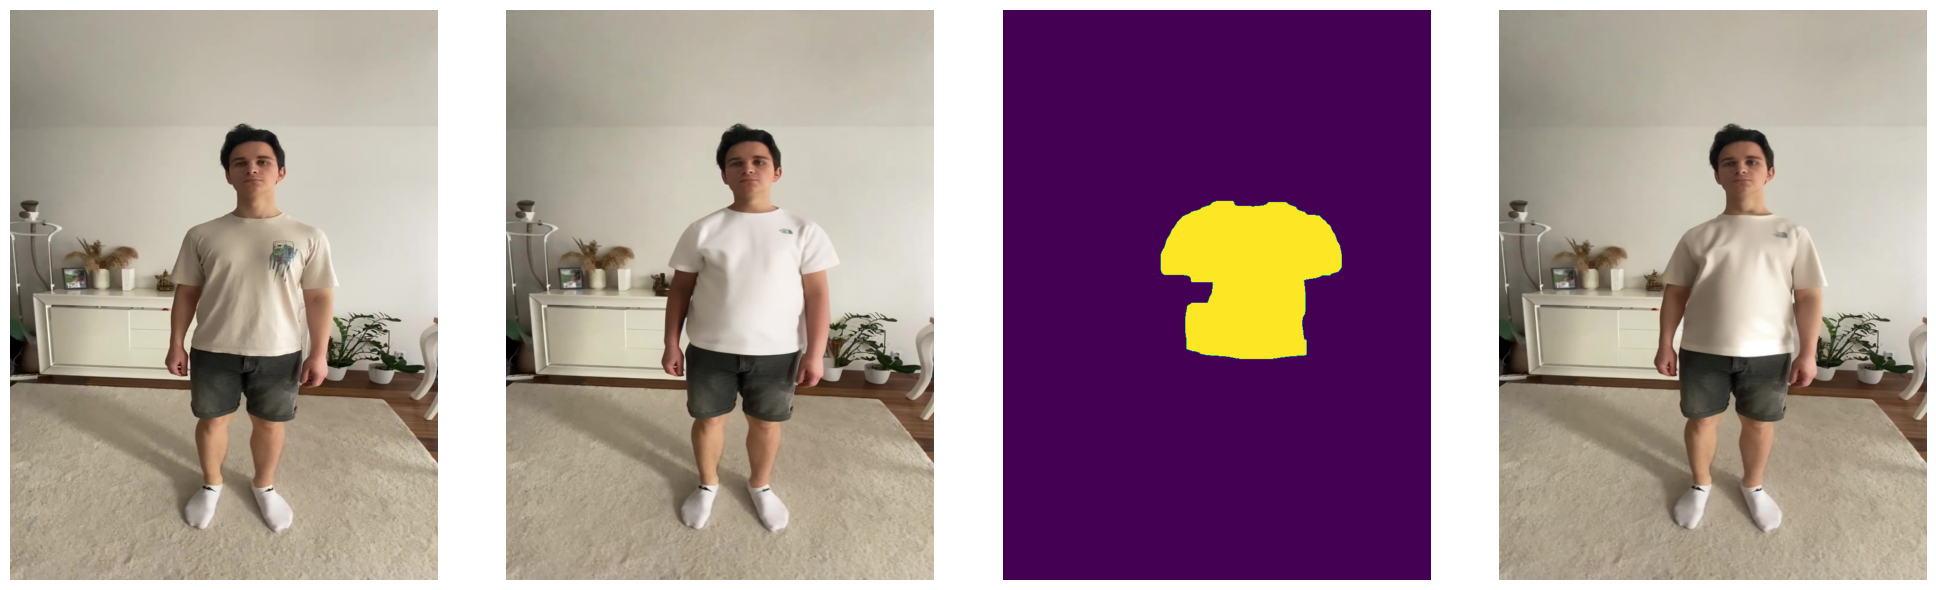

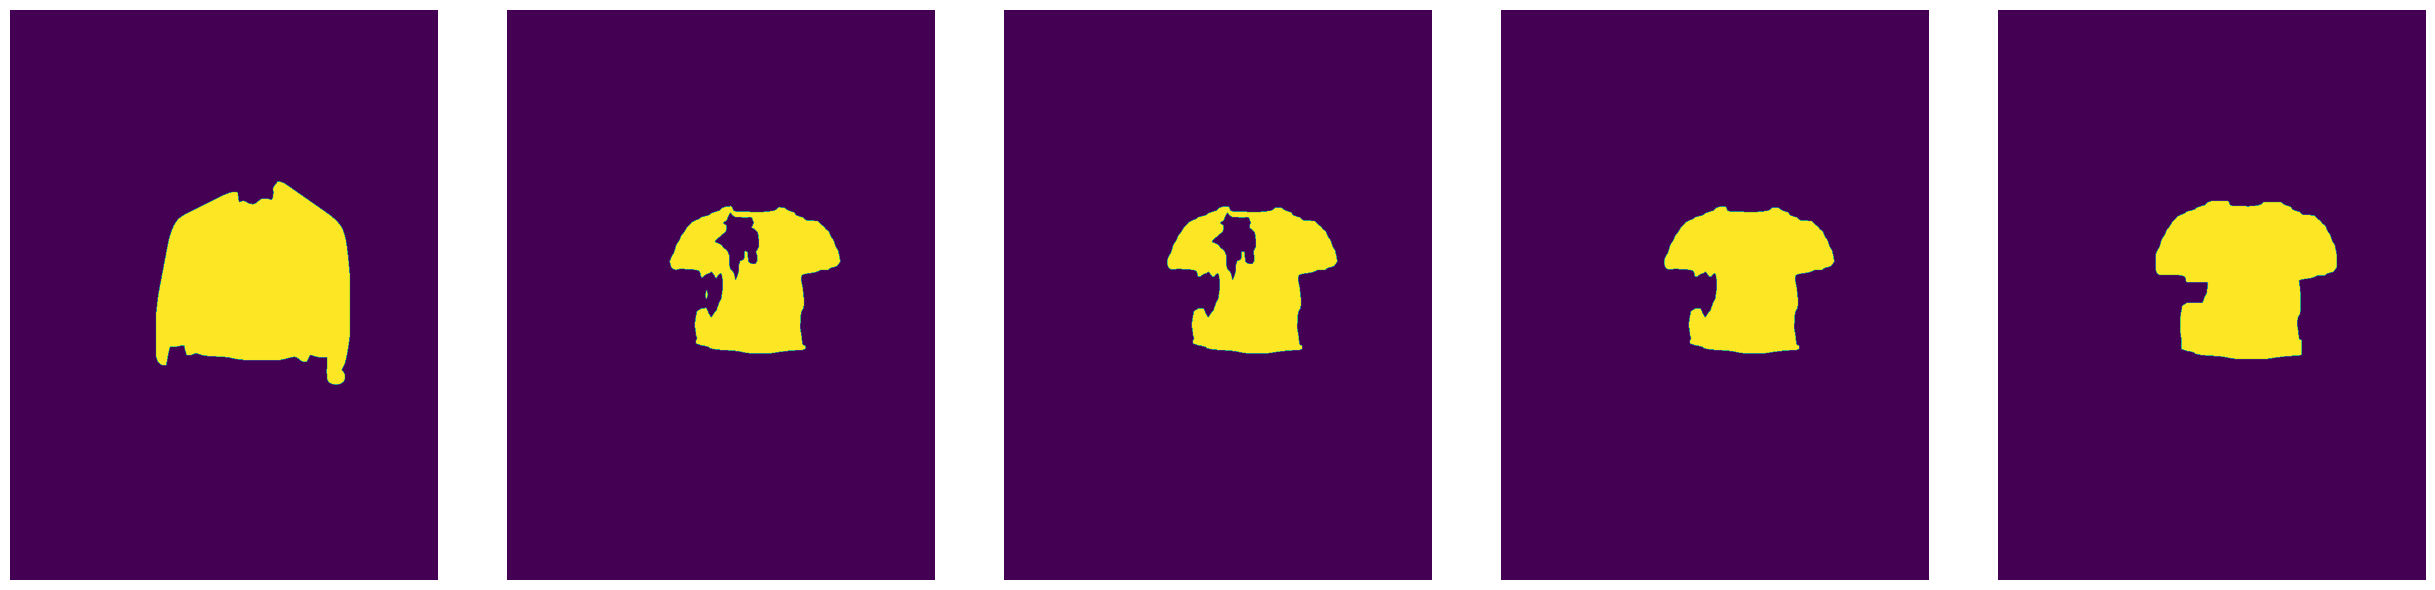

In [ ]:
# Run the two-phase pipeline
coarse_res, refined_mask, final_res, fine_mask_result, masks_refinement_steps = two_phase_tryon(front_person_img, front_garment_image, automasker, pipeline)

# Show results
print("Results: Original | Coarse Try-On | Refined Mask | Final Try-On")
show_multiple_images((front_person_img, coarse_res, refined_mask, final_res))
show_multiple_images(masks_refinement_steps)

Visualizing components of fine_mask_result:
Key: mask


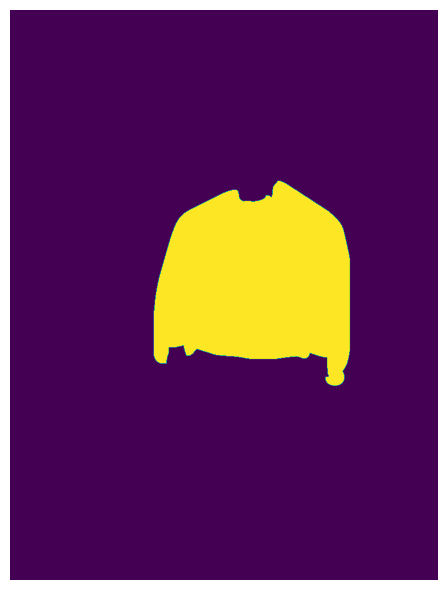

Key: densepose


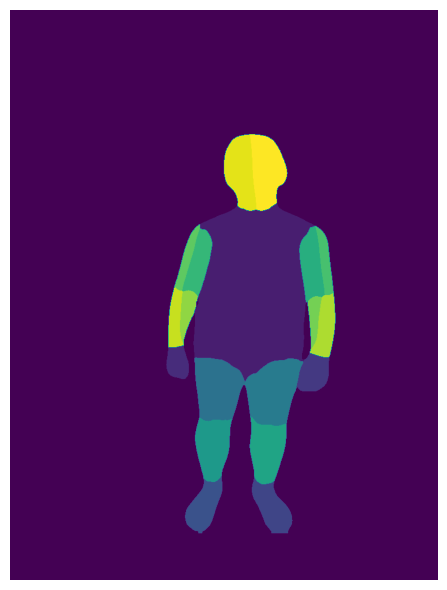

Key: schp_lip


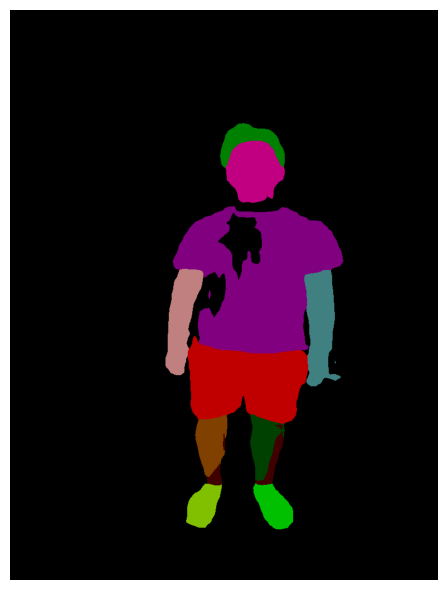

Key: schp_atr


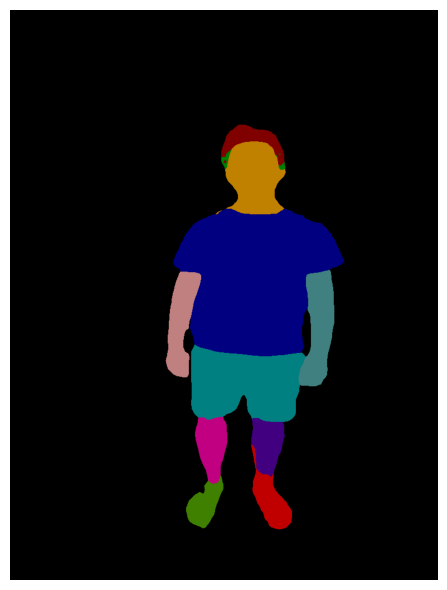

In [ ]:
print("Visualizing components of fine_mask_result:")
for key, value in fine_mask_result.items():
    print(f"Key: {key}")
    if isinstance(value, Image.Image):
        show_multiple_images([value])
    elif isinstance(value, np.ndarray):
        # Convert numpy array to PIL Image for consistent display
        show_multiple_images([Image.fromarray(value).convert("L")])
    else:
        print(f"  (Cannot display type: {type(value)})\n")


Detected Categories (SCHP ATR) in the photo:
----------------------------------------
Index 1  | Hat                  : 3221 pixels
Index 2  | Hair                 : 366 pixels
Index 4  | Upper-clothes        : 56685 pixels
Index 6  | Pants                : 21880 pixels
Index 9  | Left-shoe            : 4483 pixels
Index 10 | Right-shoe           : 3442 pixels
Index 11 | Face                 : 10684 pixels
Index 12 | Left-leg             : 4564 pixels
Index 13 | Right-leg            : 4990 pixels
Index 14 | Left-arm             : 8793 pixels
Index 15 | Right-arm            : 6972 pixels


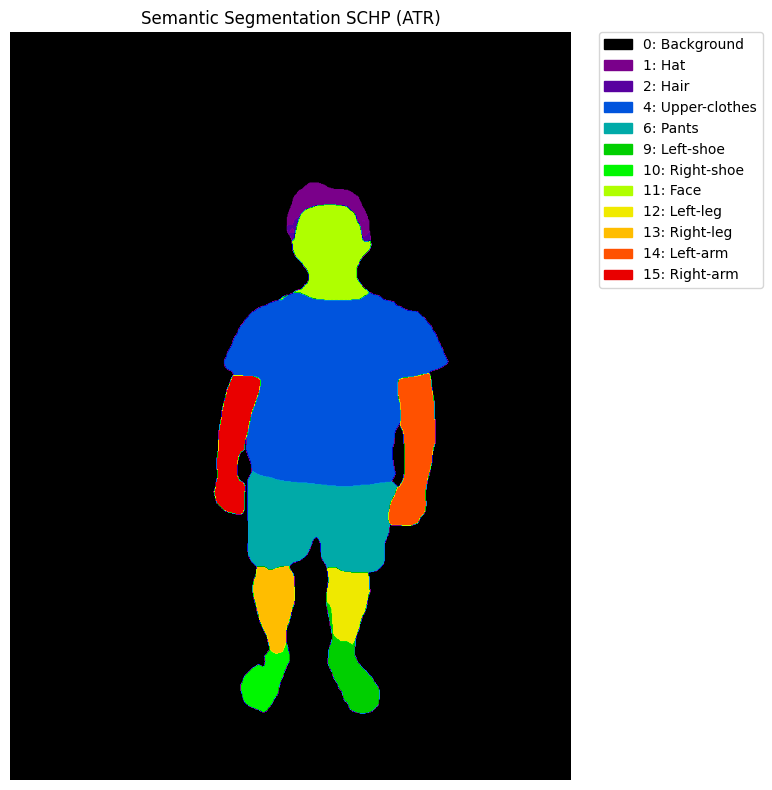

In [67]:
import matplotlib.patches as mpatches
from model.cloth_masker import ATR_MAPPING

# Create a reverse mapping (index to name)
atr_idx_to_name = {v: k for k, v in ATR_MAPPING.items()}

schp_atr_img = np.array(fine_mask_result['schp_atr'])

# Find which categories are present in the current image
unique_atr, counts_atr = np.unique(schp_atr_img, return_counts=True)
print("\nDetected Categories (SCHP ATR) in the photo:\n" + "-"*40)
for part, count in zip(unique_atr, counts_atr):
    part_name = atr_idx_to_name.get(part, "Unknown")
    if part != 0: # Skip background
        print(f"Index {part:<2} | {part_name:<20} : {count} pixels")

# Visualize the ATR map
plt.figure(figsize=(8, 8))
cmap = plt.get_cmap('nipy_spectral')
max_atr_idx = max(ATR_MAPPING.values()) if ATR_MAPPING else 17

# Ensure colors map consistently by using vmin and vmax
plt.imshow(schp_atr_img, cmap=cmap, vmin=0, vmax=max_atr_idx)
plt.title("Semantic Segmentation SCHP (ATR)")

# Create legend patches for the detected categories
patches = [mpatches.Patch(color=cmap(part / max_atr_idx), label=f"{part}: {atr_idx_to_name.get(part, 'Unknown')}") for part in unique_atr]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.axis('off')
plt.tight_layout()
plt.show()

Visualizing the 'Upper-clothes' mask directly from SCHP LIP of the front person image:


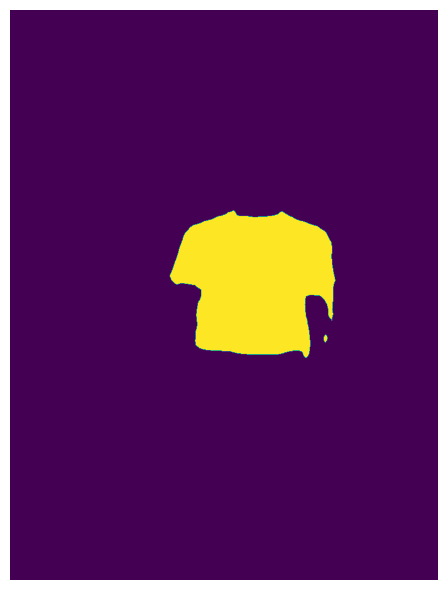

In [ ]:
# Extracting Upper-clothes mask (index 5) from the schp_lip of the original front_person_img
upper_clothes_mask_from_front_lip = (schp_lip_img == 5).astype(np.uint8) * 255
upper_clothes_mask_from_front_lip_pil = Image.fromarray(upper_clothes_mask_from_front_lip).convert("L")

print("Visualizing the 'Upper-clothes' mask directly from SCHP LIP of the front person image:")
show_multiple_images([upper_clothes_mask_from_front_lip_pil])

You can see the 'holes' here. Even in an image without explicit overlays, semantic segmentation models like `schp_lip` can interpret certain body parts or subtle features as distinct from the main 'Upper-clothes' category. Possible reasons include:

1.  **Body Contours/Shading**: Areas where the clothing is heavily creased, shadowed, or closely conforms to body parts (like armpits, elbows, or the neck region) can sometimes be ambiguous for the segmentation model, causing it to assign different labels or no label to those pixels.
2.  **Model Limitations/Training Data**: No segmentation model is perfect. The training data might not have perfectly captured every nuance of 'upper-clothes' under various lighting or pose conditions, leading to these minor inconsistencies.
3.  **Thin Straps/Features**: If the t-shirt has very thin straps or cutouts, the model might struggle to connect these regions perfectly.

This is precisely why the `two_phase_tryon` function includes several mask refinement steps (morphological opening, contour filling, and dilation) to address these imperfections and create a more solid and usable mask for the final try-on. The initial 'holes' from `schp_lip` are often corrected or smoothed out during these subsequent steps.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# The mask_result from automasker contains 'densepose' along with 'mask'
# Let's run automasker on the front image to inspect it
automasker_res = automasker(front_person_img)
densepose_img = np.array(automasker_res['densepose'])

# Find unique part indices and their pixel counts
unique_parts, counts = np.unique(densepose_img, return_counts=True)
print("DensePose parts and their pixel counts for the front view:")
for part, count in zip(unique_parts, counts):
    # 0 is usually background
    if part != 0:
        print(f"Part {part}: {count} pixels")

# Visualize the DensePose map
plt.figure(figsize=(6, 8))
plt.imshow(densepose_img, cmap='tab20')
plt.title("DensePose Part Segmentation")
plt.colorbar()
plt.axis('off')
plt.show()

# By observing which part index has the most pixels in the torso area for front vs back views,
# we can create a simple heuristic to determine the angle!

Найденные категории (SCHP LIP) на фото:
----------------------------------------
Индекс 2  | Hair            : 6348 пикселей
Индекс 5  | Upper-clothes   : 58673 пикселей
Индекс 8  | Socks           : 4386 пикселей
Индекс 9  | Pants           : 22232 пикселей
Индекс 13 | Face            : 11548 пикселей
Индекс 14 | Left-arm        : 12170 пикселей
Индекс 16 | Left-leg        : 115 пикселей
Индекс 17 | Right-leg       : 4693 пикселей
Индекс 18 | Left-shoe       : 5289 пикселей
Индекс 19 | Right-shoe      : 504 пикселей


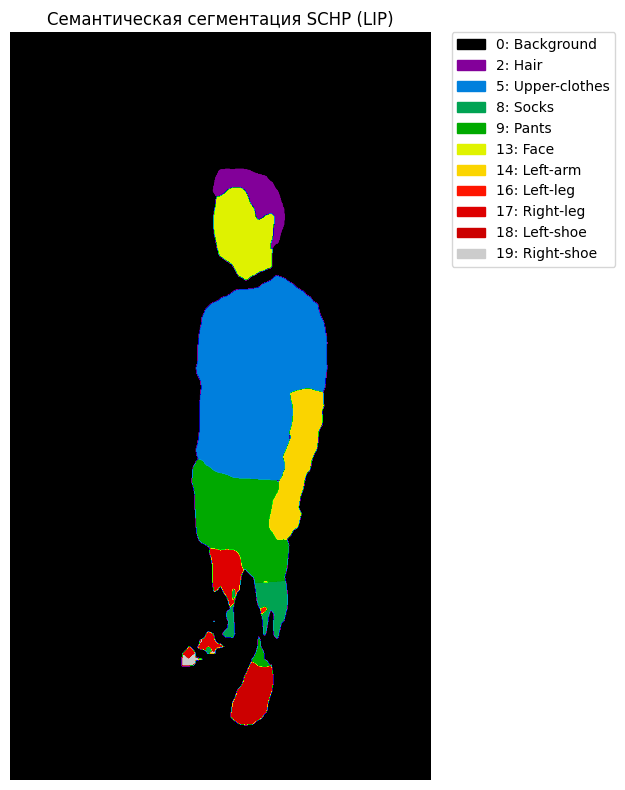

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from model.cloth_masker import LIP_MAPPING

# Извлекаем результат Human Parsing (в формате LIP)
schp_lip_img = np.array(automasker_res['schp_lip'])

# Создаем обратный маппинг из официальных классов CatVTON
lip_idx_to_name = {v: k for k, v in LIP_MAPPING.items()}

# Находим, какие категории присутствуют на текущем изображении
unique_schp, counts_schp = np.unique(schp_lip_img, return_counts=True)
print("Найденные категории (SCHP LIP) на фото:\n" + "-"*40)
for part, count in zip(unique_schp, counts_schp):
    part_name = lip_idx_to_name.get(part, "Unknown")
    if part != 0: # Пропускаем фон
        print(f"Индекс {part:<2} | {part_name:<15} : {count} пикселей")

# Визуализируем карту
plt.figure(figsize=(8, 8))
cmap = plt.get_cmap('nipy_spectral')
max_idx = max(LIP_MAPPING.values()) if LIP_MAPPING else 19

# Используем vmin и vmax для фиксации цветов
plt.imshow(schp_lip_img, cmap=cmap, vmin=0, vmax=max_idx)
plt.title("Семантическая сегментация SCHP (LIP)")

# Создаем панель-легенду
patches = [mpatches.Patch(color=cmap(part / max_idx), label=f"{part}: {lip_idx_to_name.get(part, 'Unknown')}") for part in unique_schp]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def determine_view_angle(densepose_img):
    """
    Determines if the person is facing front, back, or side based on DensePose segmentation.
    Part 1: Torso Back
    Part 2: Torso Front
    """
    densepose_array = np.array(densepose_img)

    front_torso_pixels = np.sum(densepose_array == 2)
    back_torso_pixels = np.sum(densepose_array == 1)

    total_torso = front_torso_pixels + back_torso_pixels

    if total_torso == 0:
        return "unknown"

    # Simple heuristic to determine the angle
    if front_torso_pixels > back_torso_pixels * 2:
        return "front"
    elif back_torso_pixels > front_torso_pixels * 2:
        return "back"
    else:
        return "side"

# Test it on our front image
view = determine_view_angle(densepose_img)
print(f"Detected view for front_person_img: {view}")

In [ ]:
# Body rotation angle calculation. Super incorrect now because using raw pixels as measurement,
# should use more of a metric solution/some abstract sizing)

import cv2
import math
import numpy as np
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2 import model_zoo

# 1. Initialize Detectron2 Keypoint Model
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Keypoints/keypoint_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7  # set threshold for this model
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Keypoints/keypoint_rcnn_R_50_FPN_3x.yaml")
cfg.MODEL.DEVICE = device
pose_predictor = DefaultPredictor(cfg)

# 2. Function to extract shoulder width and keypoints
def get_shoulder_width_and_kpts(img_pil):
    # Convert PIL RGB to OpenCV BGR
    img_bgr = np.array(img_pil)[:, :, ::-1]
    outputs = pose_predictor(img_bgr)

    if len(outputs["instances"]) == 0:
        return None, None

    # Get keypoints for the first detected person
    # COCO format: 5 is Left Shoulder, 6 is Right Shoulder.
    # Array shape: [17, 3] where 3 is (x, y, raw_score/logits)
    keypoints = outputs["instances"].pred_keypoints[0].cpu().numpy()

    l_shoulder = keypoints[5]
    r_shoulder = keypoints[6]

    # Lowered threshold since these are raw logits, and even visible shoulders might score slightly > 0
    if l_shoulder[2] > 0.01 and r_shoulder[2] > 0.01:
        # 2D Euclidean distance (accounts for tilt/lean)
        width = math.hypot(l_shoulder[0] - r_shoulder[0], l_shoulder[1] - r_shoulder[1])
        return width, keypoints
    return None, keypoints

# 3. Test on the front image to establish our baseline (0 degrees)
front_width, front_kpts = get_shoulder_width_and_kpts(front_person_img)

if front_width is not None:
    print(f"Baseline Front Shoulder Width: {front_width:.2f} pixels")
else:
    print("Could not detect both shoulders with sufficient confidence.")

def calculate_angle_based_on_shoulder_width(current_width, max_width):
    if current_width is None or max_width is None or max_width == 0:
        return None
    # Clamp ratio between -1.0 and 1.0 to avoid math domain errors due to slight variations
    ratio = max(min(current_width / max_width, 1.0), -1.0)
    angle_rad = math.acos(ratio)
    angle_deg = math.degrees(angle_rad)
    return angle_deg

# Example of how it calculates 0 degrees for the exact same width
if front_width is not None:
    angle = calculate_angle_based_on_shoulder_width(front_width, front_width)
    print(f"Estimated Angle for front image: {angle:.1f} degrees")

## Determine body positions per frame

In [ ]:
# Get all image files in person_folder excluding front_person_path
all_files = [
    os.path.join(person_folder, f)
    for f in os.listdir(person_folder)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

In [ ]:
body_params = {}
for file_path in tdqm(all_files):
    print(f"processing {file_path}")
    person_img = Image.open(file_path).convert("RGB")

    automasker_res = automasker(person_img)
    densepose_img = np.array(automasker_res['densepose'])

    body_params[file_path] = {'view_type': determine_view_angle(densepose_img)}
    # calculate angle
    # shoulder_width, front_kpts = get_shoulder_width_and_kpts(person_img)
    # body_params[file_path]['shoulder_width'] = shoulder_width

## Front/Back split Try-on per frame

In [ ]:
front_images = sorted([f for f in all_files
                       if os.path.abspath(f) != os.path.abspath(front_person_path)
                         and body_params[f]['view_type'] == 'front'
                       ],
                      key=os.path.basename)
back_images = sorted([f for f in all_files
                       if os.path.abspath(f) != os.path.abspath(back_person_path)
                         and body_params[f]['view_type'] == 'back'
                       ],
                      key=os.path.basename)
side_images = sorted([f for f in all_files
                       if os.path.abspath(f) != os.path.abspath(back_person_path)
                         and body_params[f]['view_type'] == 'side'
                       ],
                      key=os.path.basename)

In [ ]:
front_images_try_on_targets = front_images[::5]
back_images_try_on_targets = back_images[::5]

In [ ]:
NUM_INFERENCE_STEPS_CAT_VTON = 50

### side try-on

In [ ]:
for side_person_path in side_images: # Process every 10th image
    side_person_img = Image.open(side_person_path).convert("RGB").resize(target_size)
    print(f"\nGenerating mask for side view: {os.path.basename(side_person_path)}...")
    side_mask = automasker(side_person_img)['mask']

    # Recreate generaton so that we use the same 'random' noize for generating try-on results from all the angles
    generator = torch.Generator(device=device).manual_seed(42)

    # Tell processor to use saved features
    for proc in pipeline.unet.attn_processors.values():
        if isinstance(proc, ReferenceAttentionProcessor):
            proc.is_reference_pass = False
            proc.reset_read_index()

    side_result = pipeline(
        image=side_person_img,
        condition_image=side_garment_image,
        mask=side_mask,
        num_inference_steps=NUM_INFERENCE_STEPS_CAT_VTON,
        guidance_scale=2.5,
        generator=generator
    )[0]

    show_try_on_res(side_person_img, side_mask, side_result)

### front try-on

In [ ]:
output_folder = "/content/gaussian-splatting/input/vadim/try_on_res/input"
os.makedirs(output_folder, exist_ok=True)

# Generate masks using automasker
print("Generating mask for front view...")
front_mask = automasker(front_person_img)['mask']

# Use the same noise generator for stability
generator = torch.Generator(device=device).manual_seed(42)

print("--- PASS 1: Reference Generation (Front) ---")
# Tell processor this is a reference pass (save features)
for proc in pipeline.unet.attn_processors.values():
    if isinstance(proc, ReferenceAttentionProcessor):
        proc.is_reference_pass = True
        proc.clear_bank()

front_result = pipeline(
    image=front_person_img,
    condition_image=front_garment_image,
    mask=front_mask,
    num_inference_steps=NUM_INFERENCE_STEPS_CAT_VTON,
    guidance_scale=2.5,
    generator=generator
)[0]

# Save the front result as well to complete the set
front_filename = os.path.basename(front_person_path)
front_output_path = os.path.join(output_folder, front_filename)
front_result.save(front_output_path)
print(f"\nSaved front result to: {front_output_path}")

In [ ]:
show_try_on_res(front_person_img, front_mask, front_result)

In [ ]:
for side_person_path in front_images_try_on_targets: # Process every 10th image
    side_person_img = Image.open(side_person_path).convert("RGB").resize(target_size)
    print(f"\nGenerating mask for side view: {os.path.basename(side_person_path)}...")
    side_mask = automasker(side_person_img)['mask']

    # Recreate generaton so that we use the same 'random' noize for generating try-on results from all the angles
    generator = torch.Generator(device=device).manual_seed(42)

    # Tell processor to use saved features
    for proc in pipeline.unet.attn_processors.values():
        if isinstance(proc, ReferenceAttentionProcessor):
            proc.is_reference_pass = False
            proc.reset_read_index()

    side_result = pipeline(
        image=side_person_img,
        condition_image=front_garment_image,
        mask=side_mask,
        num_inference_steps=NUM_INFERENCE_STEPS_CAT_VTON,
        guidance_scale=2.5,
        generator=generator
    )[0]

    show_try_on_res(side_person_img, side_mask, side_result)

    # Save side result to file with the same name but in input_try-oned folder
    filename = os.path.basename(side_person_path)
    output_path = os.path.join(output_folder, filename)
    side_result.save(output_path)
    print(f"Saved try-on result to: {output_path}")

### back try-on

In [ ]:
import os


output_folder = "/content/gaussian-splatting/input/vadim/try_on_res_back/input"
os.makedirs(output_folder, exist_ok=True)

# Generate masks using automasker
print("Generating mask for back view...")
front_mask = automasker(back_person_img)['mask']

# Use the same noise generator for stability
generator = torch.Generator(device=device).manual_seed(42)

print("--- PASS 1: Reference Generation (Front) ---")
# Tell processor this is a reference pass (save features)
for proc in pipeline.unet.attn_processors.values():
    if isinstance(proc, ReferenceAttentionProcessor):
        proc.is_reference_pass = True
        proc.clear_bank()

front_result = pipeline(
    image=back_person_img,
    condition_image=back_garment_image,
    mask=front_mask,
    num_inference_steps=NUM_INFERENCE_STEPS_CAT_VTON,
    guidance_scale=2.5,
    generator=generator
)[0]

# Save the front result as well to complete the set
front_filename = os.path.basename(back_person_path)
front_output_path = os.path.join(output_folder, front_filename)
front_result.save(front_output_path)
print(f"\nSaved back result to: {front_output_path}")

In [ ]:
show_try_on_res(back_person_img, front_mask, front_result)

In [ ]:
for side_person_path in back_images_try_on_targets[::10]: # Process every 10th image
    side_person_img = Image.open(side_person_path).convert("RGB").resize(target_size)
    print(f"\nGenerating mask for side view: {os.path.basename(side_person_path)}...")
    side_mask = automasker(side_person_img)['mask']

    # Recreate generaton so that we use the same 'random' noize for generating try-on results from all the angles
    generator = torch.Generator(device=device).manual_seed(42)

    # Tell processor to use saved features
    for proc in pipeline.unet.attn_processors.values():
        if isinstance(proc, ReferenceAttentionProcessor):
            proc.is_reference_pass = False
            proc.reset_read_index()

    side_result = pipeline(
        image=side_person_img,
        condition_image=back_garment_image,
        mask=side_mask,
        num_inference_steps=NUM_INFERENCE_STEPS_CAT_VTON,
        guidance_scale=2.5,
        generator=generator
    )[0]

    show_try_on_res(side_person_img, side_mask, side_result)

    # Save side result to file with the same name but in input_try-oned folder
    filename = os.path.basename(side_person_path)
    output_path = os.path.join(output_folder, filename)
    side_result.save(output_path)
    print(f"Saved try-on result to: {output_path}")

## The same Try-on reference image for all images from all angles  

In [ ]:
# Sort the list of side person paths by filename
side_person_paths = sorted([f for f in all_files if os.path.abspath(f) != os.path.abspath(front_person_path)],
                           key=os.path.basename)

In [ ]:
side_images_try_on_targets = side_person_paths[::10]
side_images_try_on_targets

In [ ]:
import os


output_folder = "/content/gaussian-splatting/input/vadim/try_on_res/input"
os.makedirs(output_folder, exist_ok=True)

# Generate masks using automasker
print("Generating mask for front view...")
front_mask = automasker(front_person_img)['mask']

# Use the same noise generator for stability
generator = torch.Generator(device=device).manual_seed(42)

print("--- PASS 1: Reference Generation (Front) ---")
# Tell processor this is a reference pass (save features)
for proc in pipeline.unet.attn_processors.values():
    if isinstance(proc, ReferenceAttentionProcessor):
        proc.is_reference_pass = True
        proc.clear_bank()

front_result = pipeline(
    image=front_person_img,
    condition_image=garment_image,
    mask=front_mask,
    num_inference_steps=NUM_INFERENCE_STEPS_CAT_VTON,
    guidance_scale=2.5,
    generator=generator
)[0]

# Save the front result as well to complete the set
front_filename = os.path.basename(front_person_path)
front_output_path = os.path.join(output_folder, front_filename)
front_result.save(front_output_path)
print(f"\nSaved front result to: {front_output_path}")

In [ ]:
show_try_on_res(front_person_img, front_mask, front_result)

In [ ]:
for side_person_path in side_images_try_on_targets: # Process every 10th image
    side_person_img = Image.open(side_person_path).convert("RGB").resize(target_size)
    print(f"\nGenerating mask for side view: {os.path.basename(side_person_path)}...")
    side_mask = automasker(side_person_img)['mask']

    # Recreate generaton so that we use the same 'random' noize for generating try-on results from all the angles
    generator = torch.Generator(device=device).manual_seed(42)

    # Tell processor to use saved features
    for proc in pipeline.unet.attn_processors.values():
        if isinstance(proc, ReferenceAttentionProcessor):
            proc.is_reference_pass = False
            proc.reset_read_index()

    side_result = pipeline(
        image=side_person_img,
        condition_image=garment_image,
        mask=side_mask,
        num_inference_steps=NUM_INFERENCE_STEPS_CAT_VTON,
        guidance_scale=2.5,
        generator=generator
    )[0]

    show_try_on_res(side_person_img, side_mask, side_result)

    # Save side result to file with the same name but in input_try-oned folder
    filename = os.path.basename(side_person_path)
    output_path = os.path.join(output_folder, filename)
    side_result.save(output_path)
    print(f"Saved try-on result to: {output_path}")

In [ ]:
# Copy try-on results folder to Google Drive
!cp -r /content/gaussian-splatting/input/vadim/try_on_res/input /content/drive/MyDrive/weavella/images/Photos_Manual_Selection/9

## Run 3DGS training

In [ ]:
# All of these is to use GPU-accelerated version of COLMAP

# Install xvfb for OpenGL virtual display and required dependencies to build COLMAP
!sudo apt-get update
!sudo apt-get install -y xvfb cmake ninja-build \
    libboost-program-options-dev libboost-filesystem-dev libboost-graph-dev \
    libboost-system-dev libboost-test-dev libsuitesparse-dev \
    libfreeimage-dev libgoogle-glog-dev libgflags-dev \
    libglew-dev libqt5opengl5-dev qt5-qmake qtbase5-dev libceres-dev \
    libflann-dev libcgal-dev libmetis-dev

# Build COLMAP from source for GPU (CUDA) support
!rm -rf /content/colmap
!git clone --branch 3.9 https://github.com/colmap/colmap.git /content/colmap
%cd /content/colmap
!mkdir build
%cd build
!cmake .. -GNinja -DCUDA_ENABLED=ON -DCMAKE_BUILD_TYPE=Release -DCMAKE_CUDA_ARCHITECTURES=native
!ninja
!sudo ninja install

# Return to the gaussian-splatting directory
%cd /content/gaussian-splatting

In [ ]:
# Run COLMAP conversion using xvfb-run to allow OpenGL context creation
!xvfb-run python convert.py -s /content/gaussian-splatting/input/vadim/try_on_res

In [ ]:
!python train.py -s /content/gaussian-splatting/input/vadim/try_on_res/

In [ ]:
# Copy the specific training output folder to Google Drive
!cp -r /content/gaussian-splatting/output/410e2fbb-b /content/drive/MyDrive/weavella/3DGS_results/just_tests_sandbox/vadim_try_on_1_splat

# Freeze Pip versions

In [ ]:
!pip freeze > /content/requirements_locked.txt
print("Saved locked requirements to /content/requirements_locked.txt")
!head -n 10 /content/requirements_locked.txt